# Explore SDSSRM-XCS Scatter: Dependence on hot-ICM morphology

This section of the project explores potential reasons and diagnostics of galaxy cluster/group scaling relation scatter using the new SDSSRM-XCS relations constructed in this work from the properties measured in the first paper of this series [(Turner et al. 2024)](https://ui.adsabs.harvard.edu/abs/2025MNRAS.tmp...10T/abstract).

Here we examine several new SDSSRM-XCS scaling relations to see whether there are obvious correlations between the scatter of particular data points and the morphology metrics of the cluster they represent; previous work has shown that different morphological 'types' of clusters can produce distinctly different scaling relation slopes/normalisations if they are fit separately (e.g. [Mantz et al. 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.463.3582M/abstract)).

Scaling relation fits were performed using the XGA interface to the R scaling-relation fitting package LIRA, see the paper for full details.

## Main takeaways

In summary:
*  

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity
from astropy.cosmology import LambdaCDM
import pickle
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.ticker import FuncFormatter

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '..')
from common import xcs_cosmo, tx_norm, m_norm

import xga
from xga.relations.fit import scaling_relation_lira
xga.__version__

'v0.5.3+358.gb820a764'

## Setting up useful constants

Here we set up variable values that will be used repeatedly throughout this notebook, to make it easier to globally change them in the future if it becomes necessary:

In [2]:
# Color map to use for centroid shift data point colouring
CEN_SHIFT_CMAP = 'magma'
# And the equivalent for concentration colouring
CONC_CMAP = "managua"

## Loading data files and relations

We load the 'base' SDSSRM-XCS sample file, containing some basic information about galaxy cluster names, positions, and redshifts. More importantly, we load the morphology metric results newly measured for this work.

The new SDSSRM-XCS scaling relations (constructed in the course of this work) which we will explore the scatter for in this notebook are also loaded in here - note that we do not load every single relation, but rather make a representative selection. Please see the individual notebooks in the 'new_sdssrm_relations' directory for full details of the relations.

### Data files

#### SDSSRM-XCS base sample

In [3]:
sdssxcs_base = pd.read_csv("../../sample_files/SDSSRM-XCS_base_sample.csv")
sdssxcs_base.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous
0,SDSSXCS-124,124,0.80058,-6.09182,0.798261,-6.091694,0.2475,1181.028,21.202,23.203,109.550,4.490,XMMXCS J000312.1-060530.5,1.018410,True,False
1,SDSSXCS-2789,2789,0.95554,2.06802,0.956981,2.066469,0.1053,1007.861,17.194,17.202,38.904,2.830,XMMXCS J000349.3+020404.8,0.827942,True,False
2,SDSSXCS-290,290,2.72264,29.16102,2.714137,29.161154,0.3485,913.052,30.879,31.210,105.096,5.994,XMMXCS J001053.4+290939.6,1.009990,True,False
3,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True
4,SDSSXCS-134,134,4.90839,3.60982,4.911069,3.599257,0.2773,1123.321,19.219,19.226,108.604,4.792,XMMXCS J001938.0+033635.3,1.016645,True,False
5,SDSSXCS-119,119,8.46470,-7.86290,8.471426,-7.869543,0.3042,944.275,46.422,46.747,128.192,5.697,XMMXCS J003351.5-075146.4,1.050926,True,False


Calculating E(z) values for these clusters:

In [4]:
sdssxcs_base['E'] = xcs_cosmo.efunc(sdssxcs_base['z'].values)

#### SDSSRM-XCS morphology metrics

In [5]:
sdssxcs_morph = pd.read_csv("../../outputs/result_files/xmm_centshift_concentration.csv")
sdssxcs_morph.head(6)

,name,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+
0,SDSSXCS-124,0.0338,0.0009,0.0008,0.1695,0.0024,0.0026
1,SDSSXCS-2789,0.0888,0.0012,0.0012,0.1066,0.0024,0.0033
2,SDSSXCS-290,0.0096,0.0025,0.0026,0.2610,0.0134,0.0111
3,SDSSXCS-1018,0.0370,0.0019,0.0022,0.2846,0.0077,0.0091
4,SDSSXCS-134,0.0779,0.0012,0.0011,0.1737,0.0037,0.0029
5,SDSSXCS-119,0.0435,0.0082,0.0074,0.0943,0.0130,0.0107


### SDSSRM-XCS $T_{\rm{X}}$ and $L_{\rm{X}}$

In [6]:
sdssxcs_txlx = pd.read_csv("../../sample_files/paper_one_results/sdssrm-xcs_txlx_v1.0.0.csv")
sdssxcs_txlx.head(6)

,name,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lxbol_500,Lxbol_500-,Lxbol_500+,Tx_2500,Tx_2500-,Tx_2500+,Lx52_2500,Lx52_2500-,Lx52_2500+,Lxbol_2500,Lxbol_2500-,Lxbol_2500+,Tx_500ce,Tx_500ce-,Tx_500ce+,Lx52_500ce,Lx52_500ce-,Lx52_500ce+,Lxbol_500ce,Lxbol_500ce-,Lxbol_500ce+
0,SDSSXCS-124,6.92000,0.116389,0.111642,5.310408e+44,2.494586e+42,3.193270e+42,2.039754e+45,2.082091e+43,1.712354e+43,7.08946,0.097823,0.097929,4.008461e+44,2.163312e+42,1.887667e+42,1.557705e+45,1.278003e+43,1.166420e+43,6.78098,0.134306,0.158223,3.684827e+44,2.702225e+42,2.572964e+42,1.401501e+45,1.425781e+43,1.280567e+43
1,SDSSXCS-2789,4.54033,0.073600,0.074023,1.029575e+44,5.149604e+41,6.858712e+41,3.213527e+44,3.914562e+42,3.124017e+42,4.44237,0.057404,0.057774,7.125319e+43,4.164749e+41,3.793543e+41,2.201238e+44,1.767406e+42,1.642524e+42,4.65452,0.108600,0.113677,6.943669e+43,6.482835e+41,5.773788e+41,2.192642e+44,2.960496e+42,2.652251e+42
2,SDSSXCS-290,5.31681,0.297854,0.336308,2.856695e+44,5.917234e+42,7.322989e+42,9.632533e+44,4.005991e+43,3.207763e+43,5.41431,0.259989,0.309605,2.033267e+44,4.662931e+42,4.169953e+42,6.920658e+44,2.211700e+43,1.983518e+43,5.44819,0.407899,0.486340,1.972104e+44,6.434636e+42,6.092122e+42,6.734043e+44,3.038773e+43,2.687861e+43
3,SDSSXCS-1018,3.90154,0.143544,0.151498,8.044819e+43,1.441322e+42,9.241468e+41,2.335851e+44,6.385493e+42,4.924304e+42,4.09555,0.108381,0.115430,6.395952e+43,8.467201e+41,7.602523e+41,1.899850e+44,3.436098e+42,3.542190e+42,3.93098,0.207281,0.230478,5.048987e+43,1.253282e+42,1.066663e+42,1.471118e+44,5.740520e+42,4.871391e+42
4,SDSSXCS-134,6.72622,0.116523,0.116565,4.811899e+44,2.458557e+42,3.050440e+42,1.825296e+45,2.068757e+43,1.639058e+43,7.04643,0.104430,0.104760,3.813160e+44,2.170963e+42,1.872005e+42,1.479760e+45,1.263153e+43,1.208755e+43,6.37686,0.135837,0.153820,3.447715e+44,2.713877e+42,2.497416e+42,1.273855e+45,1.415497e+43,1.228583e+43
5,SDSSXCS-119,4.93456,0.400268,0.456173,2.049789e+44,5.182032e+42,6.885075e+42,6.654626e+44,4.141700e+43,3.282061e+43,5.41255,0.397709,0.448294,1.239172e+44,3.785057e+42,3.735144e+42,4.215892e+44,2.155310e+43,1.870703e+43,4.91222,0.432241,0.503558,1.821676e+44,5.522211e+42,5.714386e+42,5.900648e+44,3.822404e+43,2.772960e+43


### SDSSRM-XCS masses

In [7]:
sdssxcs_mass = pd.read_csv("../../sample_files/paper_one_results/sdssrm-xcs_mass_v1.0.0.csv")
sdssxcs_mass.head(6)

,name,Mhy500,Mhy500-,Mhy500+,Mg500,Mg500-,Mg500+,Mhy2500,Mhy2500-,Mhy2500+,Mg2500,Mg2500-,Mg2500+,Mhy500_wraderr,Mhy500_wraderr-,Mhy500_wraderr+,Mg500_wraderr,Mg500_wraderr-,Mg500_wraderr+,Mhy2500_wraderr,Mhy2500_wraderr-,Mhy2500_wraderr+,Mg2500_wraderr,Mg2500_wraderr-,Mg2500_wraderr+
0,SDSSXCS-124,7.634491,1.286289,1.029318,0.869914,0.002841,0.005951,2.621329,0.112240,0.137975,0.321744,0.000722,0.000734,7.635562,1.285474,1.041261,0.870390,0.015662,0.016223,2.621462,0.113380,0.138668,0.321697,0.007076,0.007250
1,SDSSXCS-2789,7.820374,1.259755,1.447212,0.218603,0.002491,0.002496,1.602926,0.101929,0.109311,0.097414,0.000324,0.000329,7.823912,1.268244,1.456225,0.218499,0.002874,0.002963,1.602810,0.102195,0.110153,0.097399,0.001819,0.001737
2,SDSSXCS-290,2.961604,0.369827,0.382523,0.427969,0.002132,0.002098,1.467429,0.175603,0.290465,0.134154,0.000759,0.000773,2.959792,0.390293,0.420849,0.427478,0.019454,0.019887,1.469441,0.177871,0.288247,0.134133,0.005839,0.005993
3,SDSSXCS-1018,5.067958,1.015270,0.969362,0.210208,0.001929,0.001917,1.128892,0.103503,0.149913,0.084371,0.000350,0.000359,5.072697,1.030805,0.973924,0.210059,0.003374,0.003431,1.128619,0.104011,0.149860,0.084350,0.002327,0.002330
4,SDSSXCS-134,6.802619,0.782566,0.772819,0.767290,0.002149,0.002170,3.043225,0.113304,0.110341,0.313945,0.000359,0.000367,6.803511,0.788996,0.781372,0.767157,0.010866,0.010814,3.042067,0.125878,0.124549,0.313911,0.007265,0.007068
5,SDSSXCS-119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Combining tables

In [8]:
sdssxcs_samp = pd.merge(sdssxcs_base, sdssxcs_morph, left_on='name', right_on='name', how='outer')
sdssxcs_samp = pd.merge(sdssxcs_samp, sdssxcs_txlx, left_on='name', right_on='name', how='outer')
sdssxcs_samp = pd.merge(sdssxcs_samp, sdssxcs_mass, left_on='name', right_on='name', how='outer')
sdssxcs_samp.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous,E,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lxbol_500,Lxbol_500-,Lxbol_500+,Tx_2500,Tx_2500-,Tx_2500+,Lx52_2500,Lx52_2500-,Lx52_2500+,Lxbol_2500,Lxbol_2500-,Lxbol_2500+,Tx_500ce,Tx_500ce-,Tx_500ce+,Lx52_500ce,Lx52_500ce-,Lx52_500ce+,Lxbol_500ce,Lxbol_500ce-,Lxbol_500ce+,Mhy500,Mhy500-,Mhy500+,Mg500,Mg500-,Mg500+,Mhy2500,Mhy2500-,Mhy2500+,Mg2500,Mg2500-,Mg2500+,Mhy500_wraderr,Mhy500_wraderr-,Mhy500_wraderr+,Mg500_wraderr,Mg500_wraderr-,Mg500_wraderr+,Mhy2500_wraderr,Mhy2500_wraderr-,Mhy2500_wraderr+,Mg2500_wraderr,Mg2500_wraderr-,Mg2500_wraderr+
0,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True,1.112334,0.0370,0.0019,0.0022,0.2846,0.0077,0.0091,3.90154,0.143544,0.151498,8.044819e+43,1.441322e+42,9.241468e+41,2.335851e+44,6.385493e+42,4.924304e+42,4.09555,0.108381,0.115430,6.395952e+43,8.467201e+41,7.602523e+41,1.899850e+44,3.436098e+42,3.542190e+42,3.93098,0.207281,0.230478,5.048987e+43,1.253282e+42,1.066663e+42,1.471118e+44,5.740520e+42,4.871391e+42,5.067958,1.015270,0.969362,0.210208,0.001929,0.001917,1.128892,0.103503,0.149913,0.084371,0.000350,0.000359,5.072697,1.030805,0.973924,0.210059,0.003374,0.003431,1.128619,0.104011,0.149860,0.084350,0.002327,0.002330
1,SDSSXCS-10223,10223,327.85131,-5.45000,327.845677,-5.447874,0.1402,746.039,26.739,36.742,20.049,1.960,XMMXCS J215124.3-052659.9,0.725136,False,True,1.069905,0.0473,0.0042,0.0028,0.0813,0.0071,0.0079,2.40859,0.219836,0.319837,9.122726e+42,3.091647e+41,3.160561e+41,2.176399e+43,1.124261e+42,1.413565e+42,2.19561,0.125733,0.144927,5.048276e+42,1.664598e+41,1.625227e+41,1.166650e+43,5.766516e+41,3.610387e+41,2.55083,0.316309,0.432655,7.132974e+42,2.571004e+41,3.261977e+41,1.737233e+43,1.729319e+42,1.407682e+42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SDSSXCS-103,103,117.70904,17.69577,117.753138,17.631602,0.1839,872.820,22.495,22.601,112.266,5.978,XMMXCS J075050.1+174144.7,1.023409,True,False,1.094446,0.0339,0.0016,0.0020,0.0802,0.0033,0.0028,3.27465,0.088600,0.090699,5.588176e+43,8.281677e+41,9.501838e+41,1.502258e+44,2.896692e+42,3.303122e+42,3.40941,0.084616,0.090829,2.596541e+43,2.633119e+41,4.938751e+41,7.103607e+43,1.610156e+42,1.828215e+42,3.26779,0.092742,0.096770,5.078022e+43,8.429492e+41,8.290147e+41,1.363887e+44,3.316144e+42,2.714985e+42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SDSSXCS-10401,10401,179.61596,26.49539,179.607495,26.498043,0.1411,609.736,22.255,21.940,24.794,2.297,XMMXCS J115827.8+262943.4,0.756602,False,True,1.070398,0.0115,0.0027,0.0035,0.1575,0.0075,0.0096,1.80699,0.075531,0.094081,1.896583e+43,7.551387e+41,5.234322e+41,4.118306e+43,2.179748e+42,1.636124e+42,1.87573,0.073486,0.077889,1.345144e+43,2.501362e+41,4.341628e+41,2.954728e+43,8.627745e+41,1.044296e+42,1.80056,0.086968,0.110466,1.566673e+43,8.080737e+41,8.275412e+41,3.398101e+43,1.748711e+42,2.200611e+42,0.850093,0.101953,0.144887,0.104468,0.000799,0.000786,0.297371,0.041568,0.044532,0.026583,0.000161,0.000161,0.851858,0.112813,0.154007,0.104382,0.005421,0.005593,0.297233,0.041864,0.044404,0.026583,0.001599,0.001579
4,SDSSXCS-10897,10897,170.22943,43.30579,170.232248,43.307696,0.1850,484.298,29.406,51.297,23.604,2.235,XMMXCS J112055.0+431820.8,0.749197,False,True,1.095081,0.0326,0.0101,0.0133,0.1663,0.0199,0.0258,1.21499,0.120866,0.148379,3.503914e+42,1.934199e+42,6.196028e+41,7.054035e+42,3.678029e+42,2.191543e+42,1.22924,0.069981,0.104015,1.401246e+42,2.297021e+41,4.060552e+41,2.657666e+42,5.699981e+41,5.317974e+41,1.22162,0.131562,0.217800,8.751266e+41,5.744341e+41,6.268989e+41,1.655745e+42,1.212708e+42,1.081674e+42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### SDSSRM-XCS scaling relations

#### $M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$

In [44]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-tx/turner2025_mtot500_tx500.xgarel', 'rb') as scalo:
    mtot500_tx500 = pickle.load(scalo)

#### $M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$

In [10]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-tx/turner2025_mtot2500_tx2500.xgarel', 'rb') as scalo:
    mtot2500_tx2500 = pickle.load(scalo)

#### $M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

In [11]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-lx/turner2025_mtot500_lxbol_500ce.xgarel', 'rb') as scalo:
    mtot500_lxbol_500ce = pickle.load(scalo)

#### $M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

In [12]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-lx/turner2025_mtot2500_lxbol_2500.xgarel', 'rb') as scalo:
    mtot2500_lxbol_2500 = pickle.load(scalo)

#### $M^{\rm{tot}}_{500}$-$\lambda_{\rm{RM}}$

In [13]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-richness/turner2025_mtot500_richness.xgarel', 'rb') as scalo:
    mtot500_rich = pickle.load(scalo)

#### $M^{\rm{gas}}_{500}$-$T_{\rm{X,500}}$

In [14]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-tx/turner2025_mgas500_tx500.xgarel', 'rb') as scalo:
    mgas500_tx500 = pickle.load(scalo)

#### $M^{\rm{gas}}_{2500}$-$T_{\rm{X,2500}}$

In [15]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-tx/turner2025_mgas2500_tx2500.xgarel', 'rb') as scalo:
    mgas2500_tx2500 = pickle.load(scalo)

#### $M^{\rm{gas}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

In [16]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-lx/turner2025_mgas500_lxbol_500ce.xgarel', 'rb') as scalo:
    mgas500_lxbol_500ce = pickle.load(scalo)

#### $M^{\rm{gas}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

In [17]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-lx/turner2025_mgas2500_lxbol_2500.xgarel', 'rb') as scalo:
    mgas2500_lxbol_2500 = pickle.load(scalo)

## Examining SDSSRM-XCS scaling relations with hot ICM morphology context

Here we will visualise a selection of SDSSRM-XCS scaling relations with their data points coloured by morphology metric values - this should make for a good visual indicator of whether scatter is being significantly effected by different morphologies. For instance, if it is clear that different morphologies are following distinctly different 'tracks' in the parameter space of the scaling relation.

### $M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$ 

First we examine the SDSSRM-XCS total mass - temperature mass observable relation (MOR) measured within $R_{500}$, as it is one of the lowest overall scatter relations we construct in this work. Other versions of the relation between these two parameters, e.g. the $R_{2500}$ skew, or the scatter-dominating-removed variant (see the total mass to temperature jackknifing assessment notebook), exhibit lower measured scatter, but this version includes all data points and is likely to be one of the more commonly used, hence why we have chosen it.

#### Centroid shift

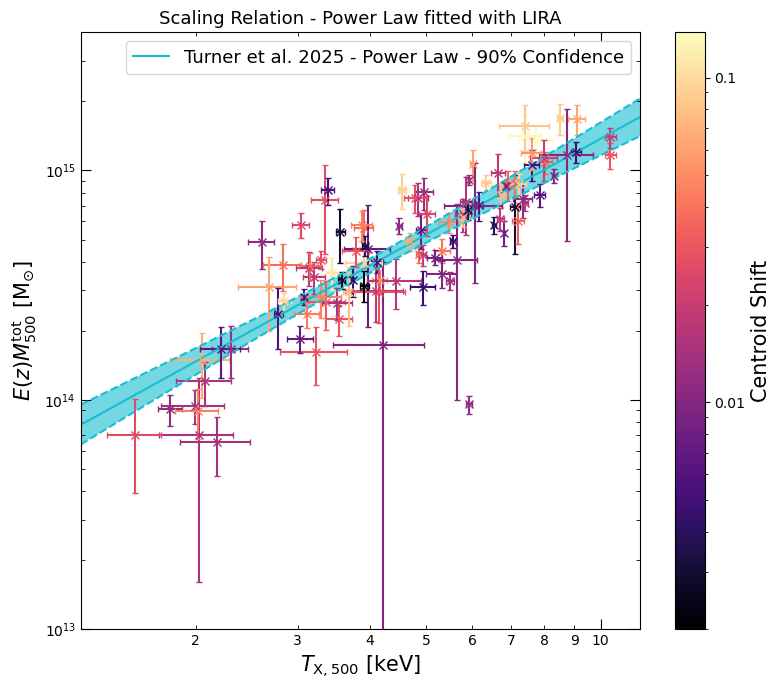

In [18]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_tx500._third_dim_info = cent_shift
mtot500_tx500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

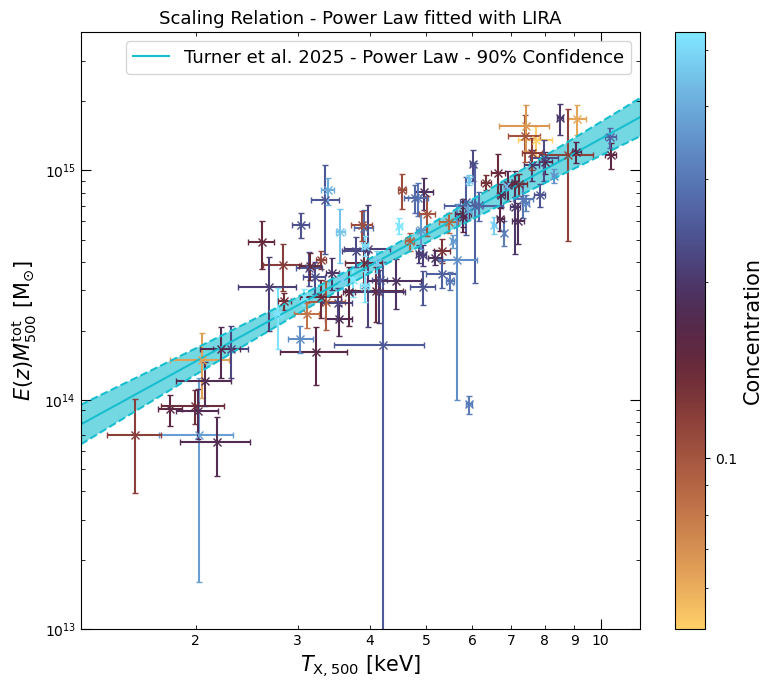

In [19]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_tx500._third_dim_info = conc
mtot500_tx500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CONC_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$ 

We will also look at the $R_{2500}$ skew of the $M_{\rm{tot}}$-$T_{\rm{X}}$ relation.

#### Centroid shift

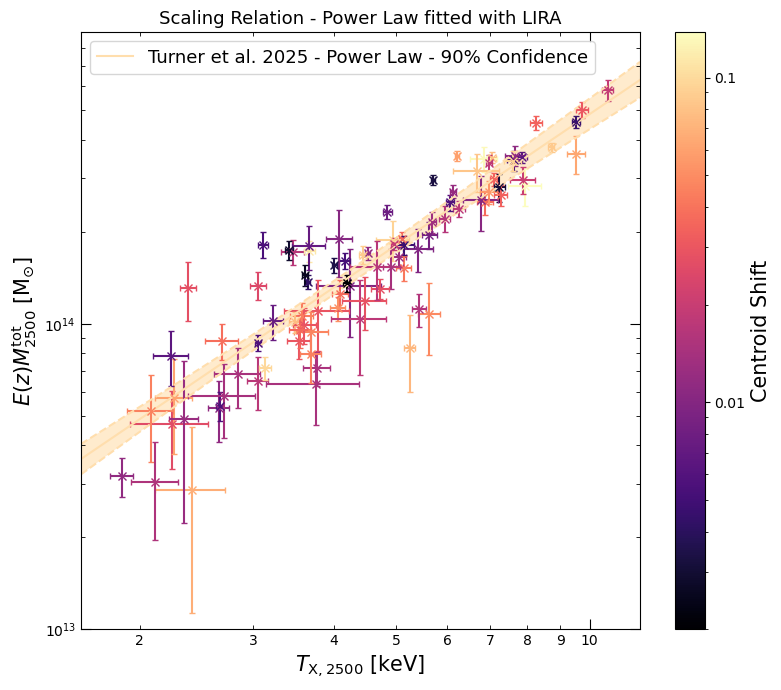

In [20]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_tx2500._third_dim_info = cent_shift
mtot2500_tx2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

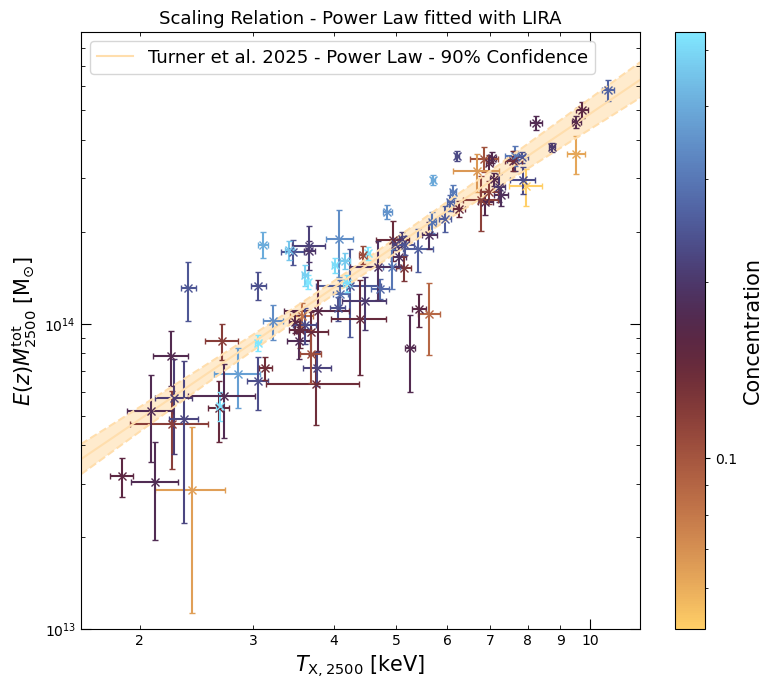

In [21]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_tx2500._third_dim_info = conc
mtot2500_tx2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

#### Centroid shift

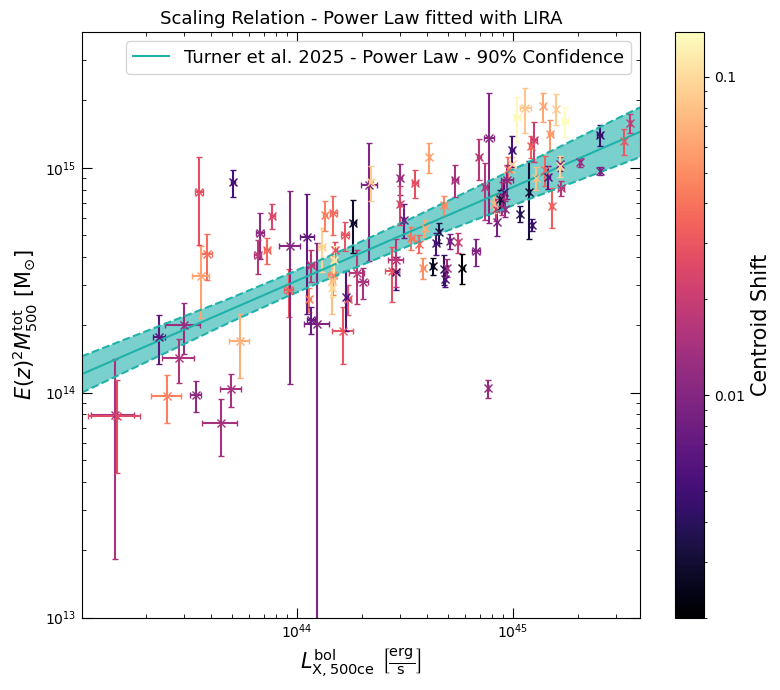

In [22]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_lxbol_500ce._third_dim_info = cent_shift
mtot500_lxbol_500ce._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

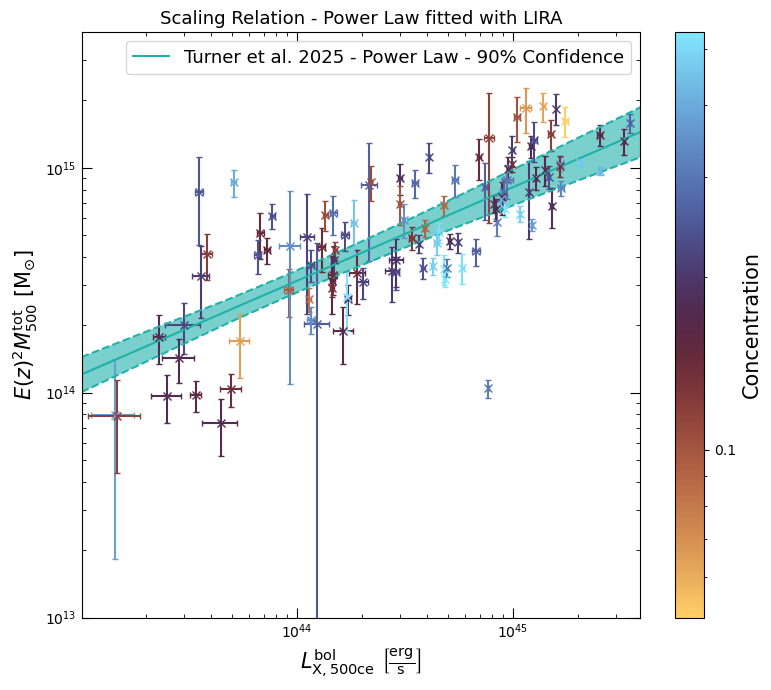

In [23]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_lxbol_500ce._third_dim_info = conc
mtot500_lxbol_500ce._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

#### Centroid shift

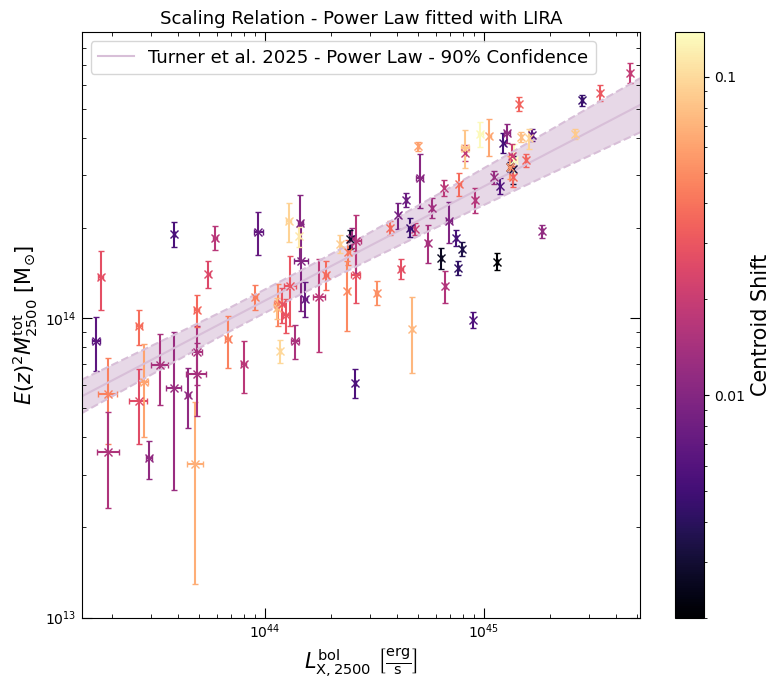

In [24]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_lxbol_2500._third_dim_info = cent_shift
mtot2500_lxbol_2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

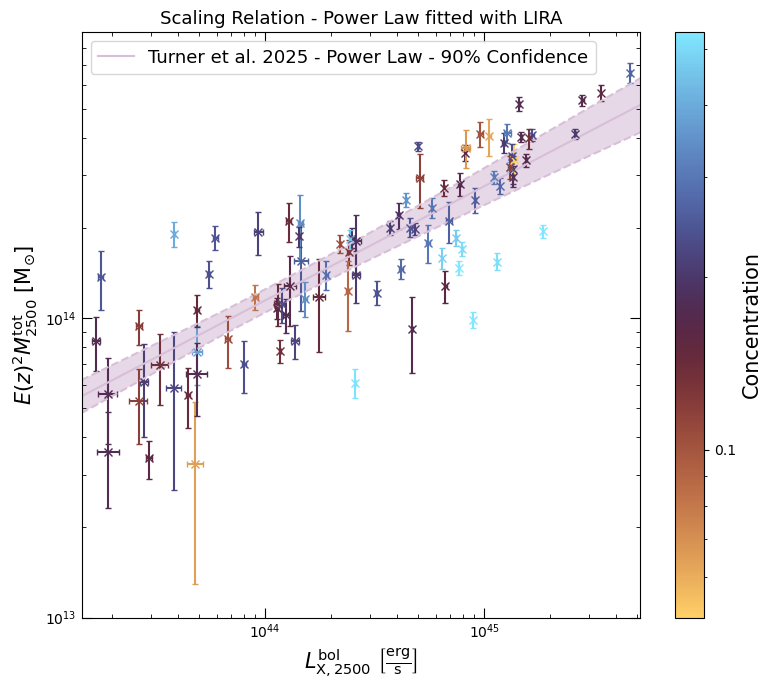

In [25]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_lxbol_2500._third_dim_info = conc
mtot2500_lxbol_2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{500}$-$\lambda_{\rm{RM}}$

#### Centroid shift

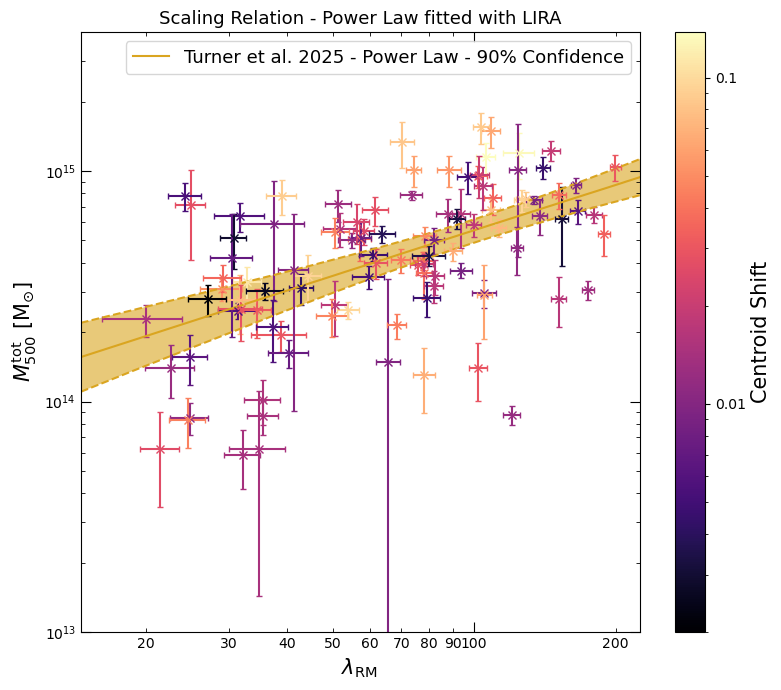

In [26]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_rich.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_rich._third_dim_info = cent_shift
mtot500_rich._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot500_rich.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                  third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

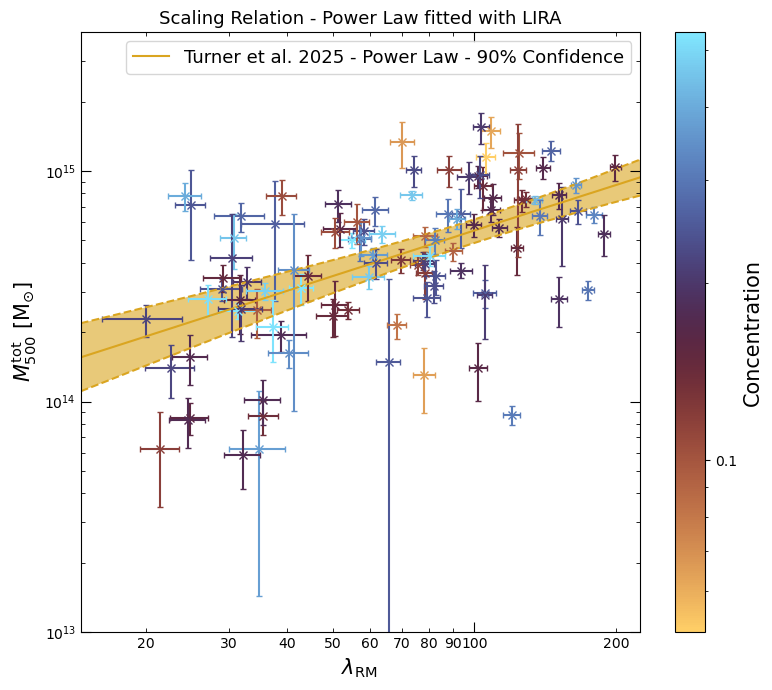

In [27]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_rich.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_rich._third_dim_info = conc
mtot500_rich._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot500_rich.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CONC_CMAP, 
                  third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{gas}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

#### Centroid shift

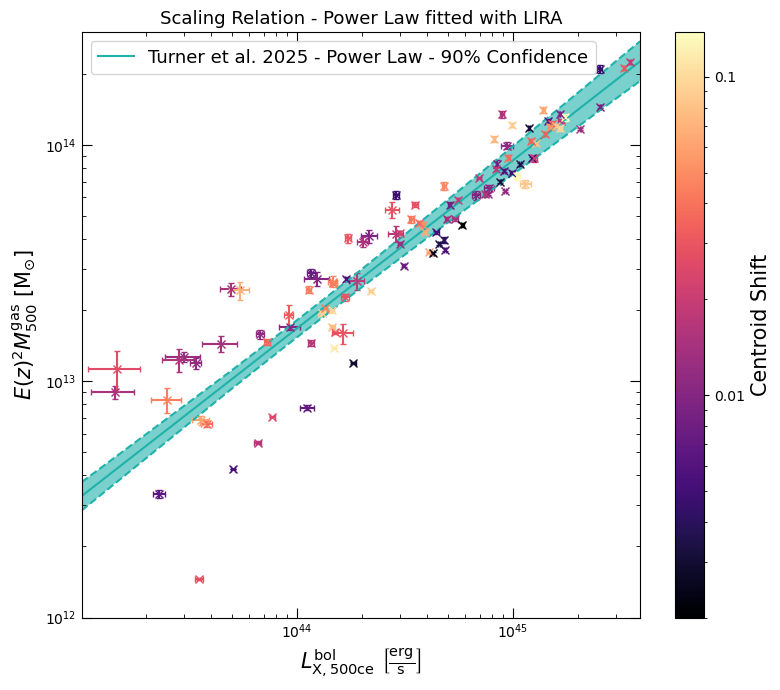

In [28]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_lxbol_500ce._third_dim_info = cent_shift
mgas500_lxbol_500ce._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

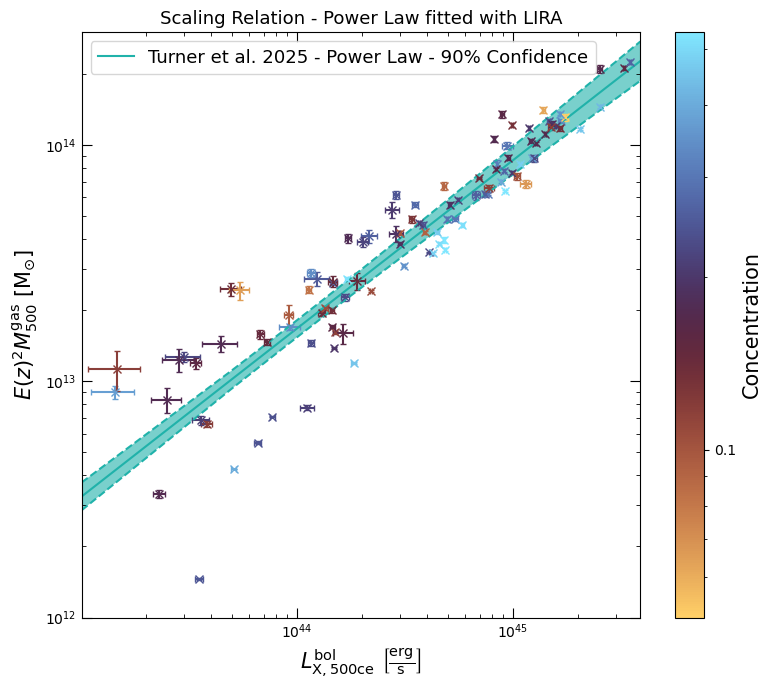

In [29]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_lxbol_500ce._third_dim_info = conc
mgas500_lxbol_500ce._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

#### Centroid shift

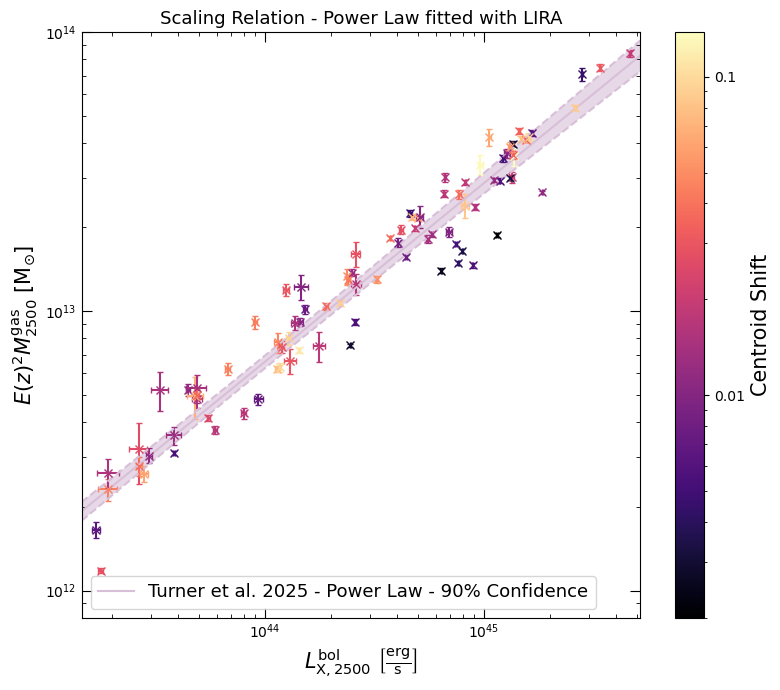

In [30]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_lxbol_2500._third_dim_info = cent_shift
mgas2500_lxbol_2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

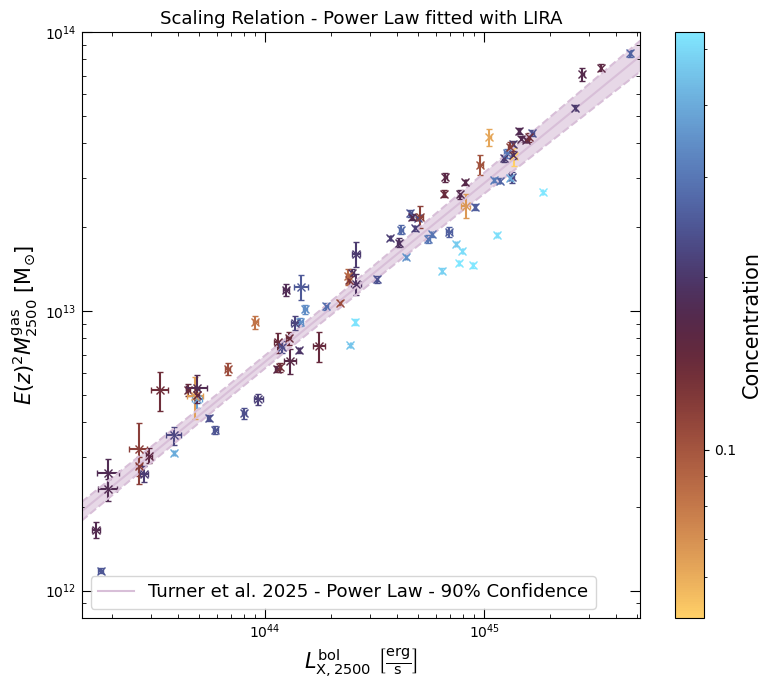

In [31]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_lxbol_2500._third_dim_info = conc
mgas2500_lxbol_2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{gas}}_{500}$-$T_{\rm{X,500}}$ 

#### Centroid shift

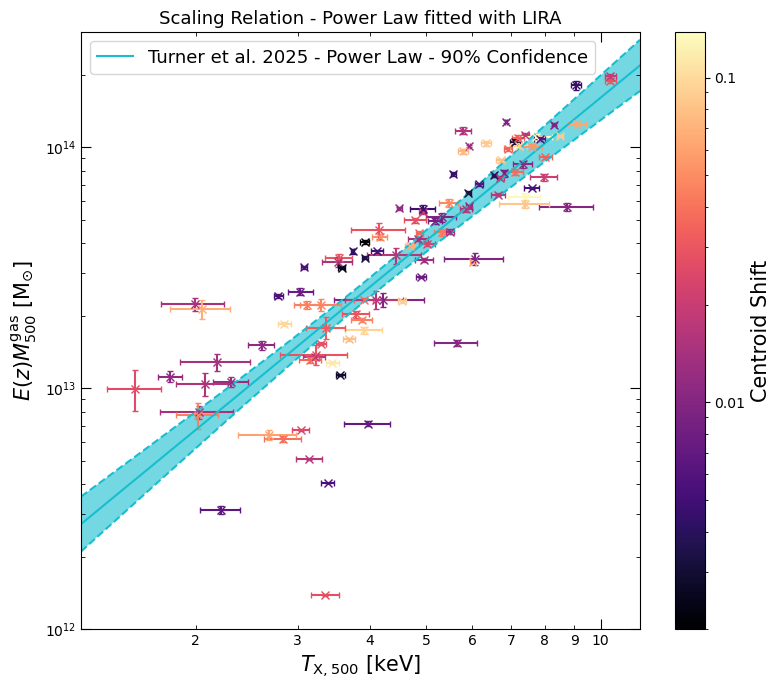

In [32]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_tx500._third_dim_info = cent_shift
mgas500_tx500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

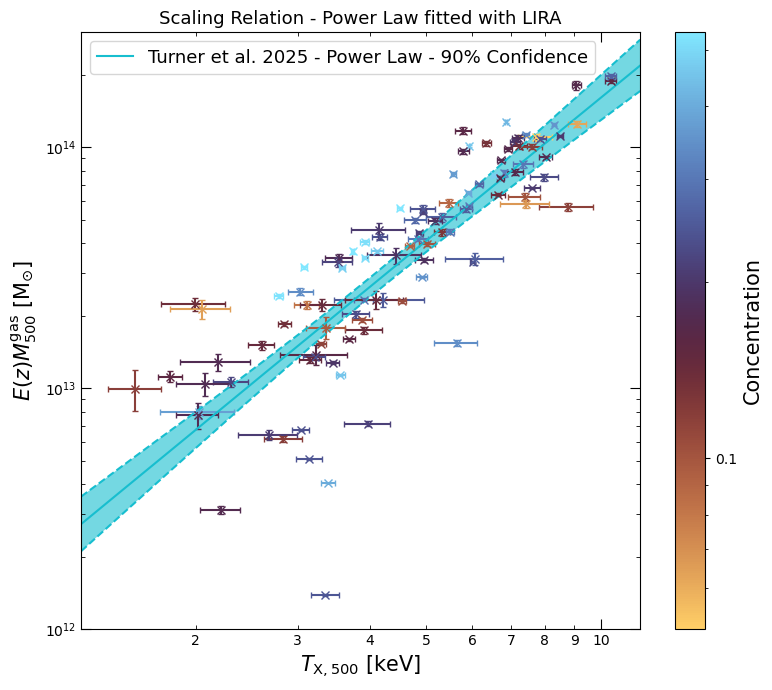

In [33]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_tx500._third_dim_info = conc
mgas500_tx500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$ 

#### Centroid shift

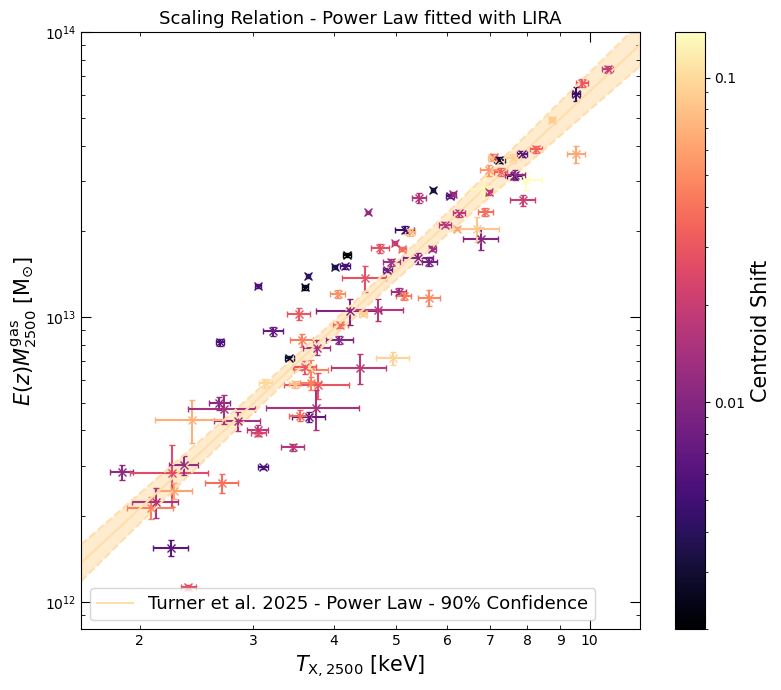

In [34]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_tx2500._third_dim_info = cent_shift
mgas2500_tx2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

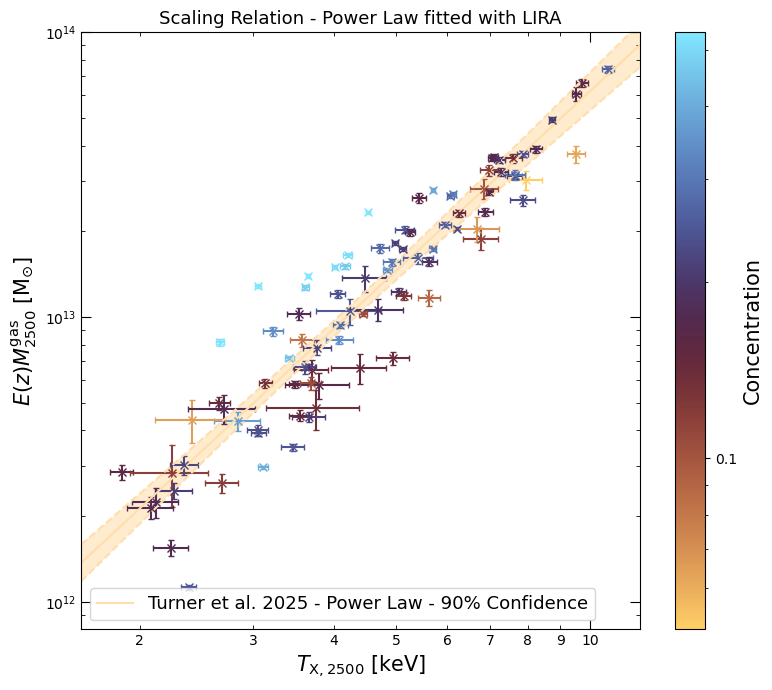

In [35]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_tx2500._third_dim_info = conc
mgas2500_tx2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

## Visualizing morphology metrics

### Histograms

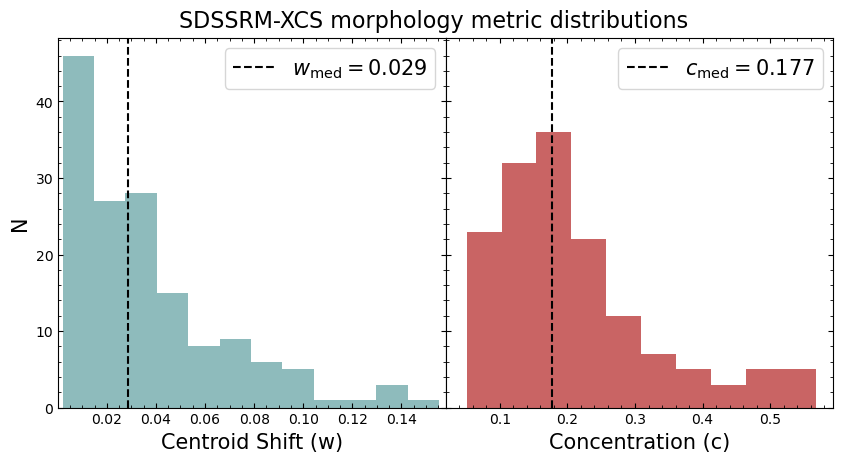

In [109]:
fig, ax_arr = plt.subplots(ncols=2, figsize=(10, 4.8), sharey=True)
fig.subplots_adjust(wspace=0)

# Set the ticks up as we like them
for ax in ax_arr:
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

# Plot the centroid shift distribution
ax = ax_arr[0]
plt.sca(ax)
plt.hist(sdssxcs_samp['cen_shift'], bins='auto', color='cadetblue', alpha=0.7)
# Calculate and add the median value
cs_med = np.median(sdssxcs_samp['cen_shift'].values)
plt.axvline(cs_med, color='black', linestyle='dashed', label=r'$w_{\rm{med}}=' + str(round(cs_med, 3)) + "$")
# Limit and label the axes
plt.xlim(0.0002, 0.158)
plt.xlabel('Centroid Shift (w)', fontsize=15)
plt.ylabel('N', fontsize=15)
# This axes' legend
plt.legend(fontsize=15)

# Plot the concentration distribution
ax = ax_arr[1]
plt.sca(ax)
plt.hist(sdssxcs_samp['concentration'], bins='auto', color='firebrick', alpha=0.7)
# Calculate and add the median value
c_med = np.median(sdssxcs_samp['concentration'].values)
plt.axvline(c_med, color='black', linestyle='dashed', label=r'$c_{\rm{med}}=' + str(round(c_med, 3)) + "$")
plt.xlim(0.02)
plt.xlabel('Concentration (c)', fontsize=15)
# This axes' legend
plt.legend(fontsize=15)
plt.suptitle("SDSSRM-XCS morphology metric distributions", fontsize=16, y=0.94)

plt.show()

### Relaxed and disturbed $c-w$ plane with limits from [Lovisari et al. 2017](https://ui.adsabs.harvard.edu/abs/2017ApJ...846...51L/abstract)

Use the $c-w$ plane limits that Lovisari et al. found were most effective at selecting relaxed galaxy clusters:

In [179]:
sdssxcs_samp['lovisari_relaxed'] = (sdssxcs_samp['concentration'] > 0.15) & (sdssxcs_samp['cen_shift'] < 2.1e-2)
sdssxcs_samp['lovisari_relaxed'].value_counts()

lovisari_relaxed
False    94
True     56
Name: count, dtype: int64

Make a visualization of the plane with the relaxed and not-relaxed systems shown in different colours:

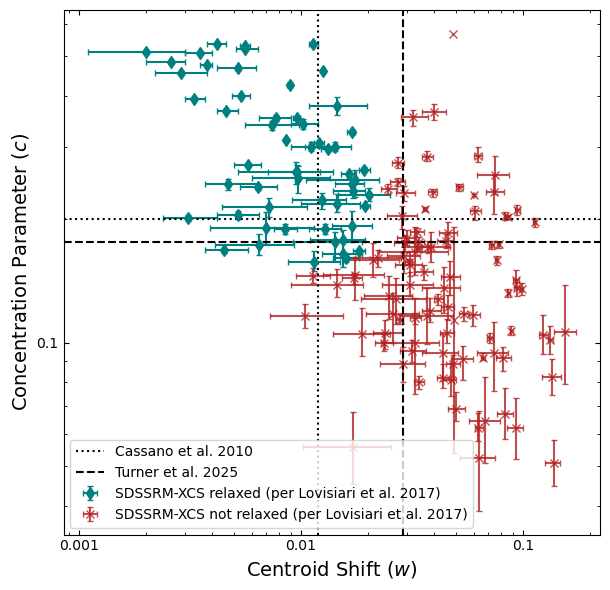

In [183]:
# We find systems that (per the Lovisari limts in Table 2 of their paper) are relaxed
sdssxcs_samp_app_relaxed = sdssxcs_samp[sdssxcs_samp['lovisari_relaxed']]
# And define everything else as 'not relaxed' (which doesn't necessarily mean disturbed, at least in my head - it 
#  isn't as simple as a cluster being one thing or another)
sdssxcs_samp_app_not_relaxed = sdssxcs_samp[~sdssxcs_samp['lovisari_relaxed']]

# Making another version of the figure in the morphology notebook, might well transplant this there
plt.figure(figsize=(6.2, 6))

plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

# First the apparently relaxed
plt.errorbar(sdssxcs_samp_app_relaxed['cen_shift'], sdssxcs_samp_app_relaxed['concentration'], 
             xerr=sdssxcs_samp_app_relaxed[['cen_shift-', 'cen_shift+']].values.T, 
             yerr=sdssxcs_samp_app_relaxed[['concentration-', 'concentration+']].values.T, 
             fmt='d', color='teal', label='SDSSRM-XCS relaxed (per Lovisiari et al. 2017)', capsize=2) 
# And the apparently not relaxed
plt.errorbar(sdssxcs_samp_app_not_relaxed['cen_shift'], sdssxcs_samp_app_not_relaxed['concentration'], 
             xerr=sdssxcs_samp_app_not_relaxed[['cen_shift-', 'cen_shift+']].values.T, 
             yerr=sdssxcs_samp_app_not_relaxed[['concentration-', 'concentration+']].values.T, 
             fmt='x', color='firebrick', label='SDSSRM-XCS not relaxed (per Lovisiari et al. 2017)', capsize=2, 
             alpha=0.8) 

# Cassano medians (I think?)
plt.axvline(0.012, color='black', linestyle='dotted', label="Cassano et al. 2010")
plt.axhline(0.2, color='black', linestyle='dotted')

# Our medians!
plt.axvline(cs_med, color='black', linestyle='dashed', label="Turner et al. 2025")
plt.axhline(c_med, color='black', linestyle='dashed')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"Centroid Shift ($w$)", fontsize=14)
plt.ylabel(r"Concentration Parameter ($c$)", fontsize=14)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda inp, _: '{:g}'.format(inp)))

plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Separately fitting relations to 'relaxed' and 'disturbed' clusters

We split on [Lovisari et al. 2017](https://ui.adsabs.harvard.edu/abs/2017ApJ...846...51L/abstract) $c-w$ plane classification of relaxed clusters, in order to explore how much various mass-observable relations are impacted by the dynamical state of the galaxy clusters, and whether potential users of the relations should attempt to ascertain the hot-ICM morphology before using MORs. 


<span style='color:red'>**Have to figure out the best way of doing this, possibly it is using the scatter dominating excluded samples for each relation**</span>

In [58]:
bad_sel = sdssxcs_samp['name'] == 'SDSSXCS-22'
sdssxcs_samp.loc[bad_sel, ['Mhy500_wraderr', 'Mhy500_wraderr-', 'Mhy500_wraderr+']] = np.array([np.nan, np.nan, np.nan])

Setting up common values:

In [ ]:
# Most of these will be total-mass observable relations, so we'll set this up here
mtot500 = Quantity(sdssxcs_samp[['Mhy500_wraderr', 'Mhy500_wraderr-', 'Mhy500_wraderr+']].values*1e+14, 'Msun')\
    *sdssxcs_samp['E'].values[..., None]

# Read out the cluster names, remember we label each point with them
clust_names = sdssxcs_samp['name'].values

### $M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$

In [124]:
# Setting up property variables in astropy quantity objects
tx500 = Quantity(sdssxcs_samp[['Tx_500', 'Tx_500-','Tx_500+']].values, 'keV')

#### Relaxed

In [195]:
rel_mtot500 = mtot500[sdssxcs_samp['lovisari_relaxed'].values, :]
rel_tx500 = tx500[sdssxcs_samp['lovisari_relaxed'].values, :]
rel_names = clust_names[sdssxcs_samp['lovisari_relaxed'].values]

rel_mtot500_tx500 = scaling_relation_lira(rel_mtot500[:, 0], rel_mtot500[:, 1:], rel_tx500[:, 0], rel_tx500[:, 1:], 
                                          m_norm, tx_norm, y_name=r"$E(z)M^{\rm{tot}}_{500}$", x_name=r"$T_{\rm{X,500}}$", 
                                          dim_hubb_ind=1, point_names=rel_names)
rel_mtot500_tx500.model_colour = 'cadetblue'
rel_mtot500_tx500.author = 'Turner et al.'
rel_mtot500_tx500.year = 2025
rel_mtot500_tx500.name = r'Relaxed'

/Users/dt237/code/XGA/xga/relations/fit.py:414: UserWarning: 4 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/XGA/xga/relations/fit.py:450: UserWarning: 4 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


#### Unrelaxed

In [196]:
unrel_mtot500 = mtot500[~sdssxcs_samp['lovisari_relaxed'].values, :]
unrel_tx500 = tx500[~sdssxcs_samp['lovisari_relaxed'].values, :]
unrel_names = clust_names[~sdssxcs_samp['lovisari_relaxed'].values]

unrel_mtot500_tx500 = scaling_relation_lira(unrel_mtot500[:, 0], unrel_mtot500[:, 1:], unrel_tx500[:, 0], unrel_tx500[:, 1:], 
                                            m_norm, tx_norm, y_name=r"$E(z)M^{\rm{tot}}_{500}$", x_name=r"$T_{\rm{X,500}}$", 
                                            dim_hubb_ind=1, point_names=unrel_names)
unrel_mtot500_tx500.model_colour = 'steelblue'
unrel_mtot500_tx500.author = 'Turner et al.'
unrel_mtot500_tx500.year = 2025
unrel_mtot500_tx500.name = r'Unrelaxed'

  |**************************************************| 100%


#### Comparison figure & corner plot

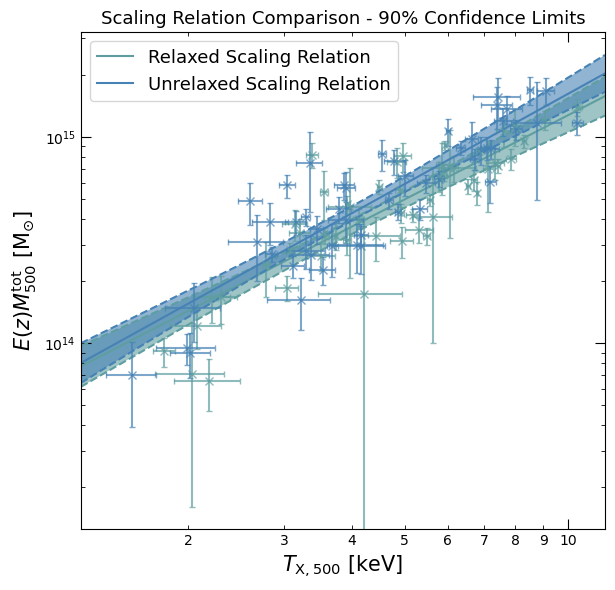

In [201]:
(rel_mtot500_tx500 + unrel_mtot500_tx500).view(figsize=(6.25, 6), )

Removed no burn in
Removed no burn in


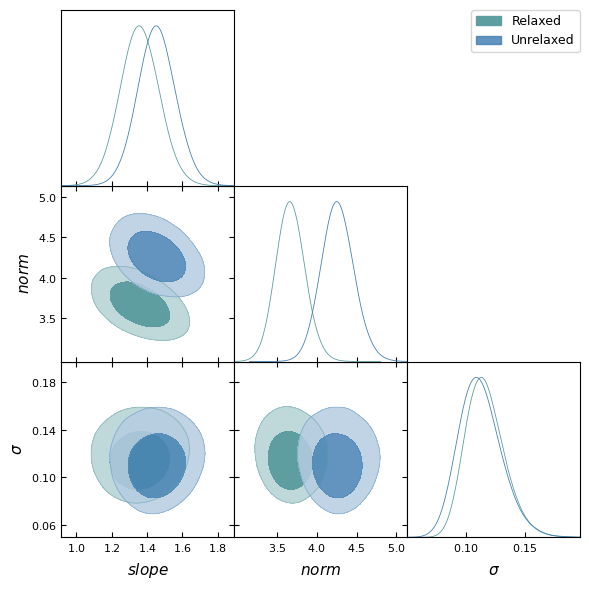

In [199]:
(rel_mtot500_tx500 + unrel_mtot500_tx500).view_corner(figsize=(6, 6))

### $M^{\rm{tot}}_{500}$-$T_{\rm{X,500ce}}$

In [202]:
# Setting up property variables in astropy quantity objects
tx500ce = Quantity(sdssxcs_samp[['Tx_500ce', 'Tx_500ce-','Tx_500ce+']].values, 'keV')

#### Relaxed

In [203]:
rel_mtot500 = mtot500[sdssxcs_samp['lovisari_relaxed'].values, :]
rel_tx500ce = tx500ce[sdssxcs_samp['lovisari_relaxed'].values, :]
rel_names = clust_names[sdssxcs_samp['lovisari_relaxed'].values]

rel_mtot500_tx500ce = scaling_relation_lira(rel_mtot500[:, 0], rel_mtot500[:, 1:], rel_tx500ce[:, 0], rel_tx500ce[:, 1:], 
                                            m_norm, tx_norm, y_name=r"$E(z)M^{\rm{tot}}_{500}$", x_name=r"$T_{\rm{X,500ce}}$", 
                                            dim_hubb_ind=1, point_names=rel_names)
rel_mtot500_tx500ce.model_colour = 'cadetblue'
rel_mtot500_tx500ce.author = 'Turner et al.'
rel_mtot500_tx500ce.year = 2025
rel_mtot500_tx500ce.name = r'Relaxed'

/Users/dt237/code/XGA/xga/relations/fit.py:414: UserWarning: 4 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/XGA/xga/relations/fit.py:450: UserWarning: 4 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


#### Unrelaxed

In [204]:
unrel_mtot500 = mtot500[~sdssxcs_samp['lovisari_relaxed'].values, :]
unrel_tx500ce = tx500ce[~sdssxcs_samp['lovisari_relaxed'].values, :]
unrel_names = clust_names[~sdssxcs_samp['lovisari_relaxed'].values]

unrel_mtot500_tx500ce = scaling_relation_lira(unrel_mtot500[:, 0], unrel_mtot500[:, 1:], unrel_tx500ce[:, 0], unrel_tx500ce[:, 1:], 
                                              m_norm, tx_norm, y_name=r"$E(z)M^{\rm{tot}}_{500}$", x_name=r"$T_{\rm{X,500ce}}$", 
                                              dim_hubb_ind=1, point_names=unrel_names)
unrel_mtot500_tx500ce.model_colour = 'steelblue'
unrel_mtot500_tx500ce.author = 'Turner et al.'
unrel_mtot500_tx500ce.year = 2025
unrel_mtot500_tx500ce.name = r'Unrelaxed'

/Users/dt237/code/XGA/xga/relations/fit.py:414: UserWarning: 43 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/XGA/xga/relations/fit.py:450: UserWarning: 43 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


#### Comparison figure & corner plot

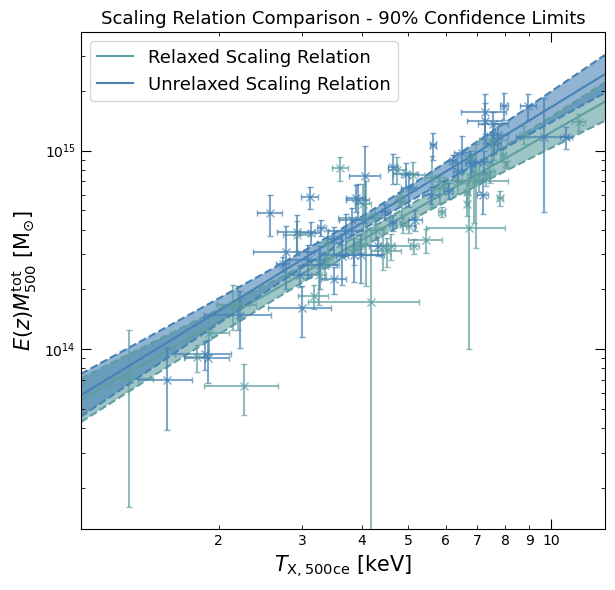

In [205]:
(rel_mtot500_tx500ce + unrel_mtot500_tx500ce).view(figsize=(6.25, 6), )

Removed no burn in
Removed no burn in


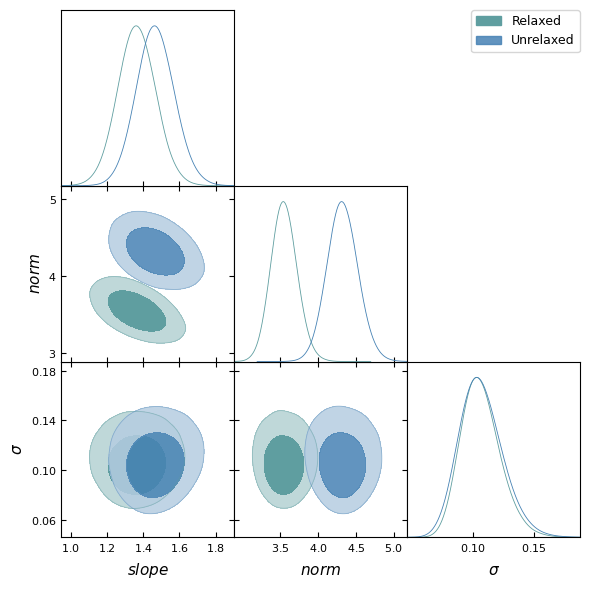

In [206]:
(rel_mtot500_tx500ce + unrel_mtot500_tx500ce).view_corner(figsize=(6, 6))